<a href="https://colab.research.google.com/github/ozgenurunlu/ozgenurunlu/blob/main/BitirmeProjem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Havayolları Müşteri Memnuniyet Analizi

✈️ **VERİSETİMİZDEKİ DEĞİŞKENLER**

***Gender*** :Yolcunun cinsiyeti (Kadın, Erkek)

***Customer Type:*** Yolcunun müşteri tipi (Sadık müşteri, Sadık olmayan müşteri)

***Age:*** Yolcunun gerçek yaşı

***Type of Travel:*** Yolcunun seyahat amacı (Kişisel seyahat, İş seyahati)

***Class:*** Uçakta seyahat edilen sınıf (Business, Ekonomi, Ekonomi Plus)

***Flight Distance:*** Bu yolculuktaki uçuş mesafesi

🧑‍✈️**Hizmet Memnuniyeti Değerlendirmeleri**

(0: Uygulanamaz, 1–5: Memnuniyet düzeyi)

***Inflight wifi service:*** Uçak içi Wi-Fi hizmetinden memnuniyet

***Departure/Arrival time convenient:*** Kalkış/varış zamanının uygunluğu

***Ease of Online booking:*** Online bilet alma kolaylığı

***Gate location:*** Kapı konumundan memnuniyet

***Food and drink:*** Yiyecek ve içecek hizmetinden memnuniyet

***Online boarding:*** Online biniş işlemlerinden memnuniyet

***Seat comfort:*** Koltuk rahatlığı

***Inflight entertainment:*** Uçak içi eğlence sisteminden memnuniyet

***On-board service:*** Genel uçak içi hizmet kalitesi

***Leg room service:*** Bacak mesafesinden memnuniyet

***Baggage handling:*** Bagaj işlemlerinden memnuniyet

***Check-in service:*** Check-in hizmetinden memnuniyet

***Inflight service:*** Uçuş sırasındaki genel hizmet kalitesi

***Cleanliness:*** Uçağın temizliğinden memnuniyet

⏱️**Zaman Verileri**

***Departure Delay in Minutes:*** Kalkıştaki gecikme süresi (dakika olarak)

***Arrival Delay in Minutes:*** Varıştaki gecikme süresi (dakika olarak)


# Veri Setimizi Yükleme

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("train.csv.csv",index_col=0) #verisetinde indeksler ilk sütunda verildiği için index_col parametresi kullanıldı.
df.head(5)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Veriye Genel Bakış
Veri setini tanımak ve değişkenleri anlamak amaçlandı

In [4]:
df.shape

(103904, 24)

Veri setimizde 103904 müşterinin bilgileri bulunuyor ve 24 değişkenimiz var.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [6]:
df.dtypes.value_counts()

,count
int64,18
object,5
float64,1


# Görselleştirmeden Önce Yapılması Gerekenler
# 1.Kayıp Veri İle Uğraşma

In [11]:
#eksik veri sayısı
missing_counts=df.isnull().sum().sort_values(ascending=False)

# Eksik veri oranı
missing_ratio = (df.isnull().sum() / len(df)) * 100

# Kayıp veri tablosu
missing_df = pd.DataFrame({"Eksik Değer Sayısı": missing_counts, "Oran (%)": missing_ratio})
missing_df = missing_df[missing_df["Eksik Değer Sayısı"] > 0]
missing_df.sort_values("Oran (%)", ascending=False, inplace=True)

print(missing_df)

                          Eksik Değer Sayısı  Oran (%)
Arrival Delay in Minutes                 310  0.298352


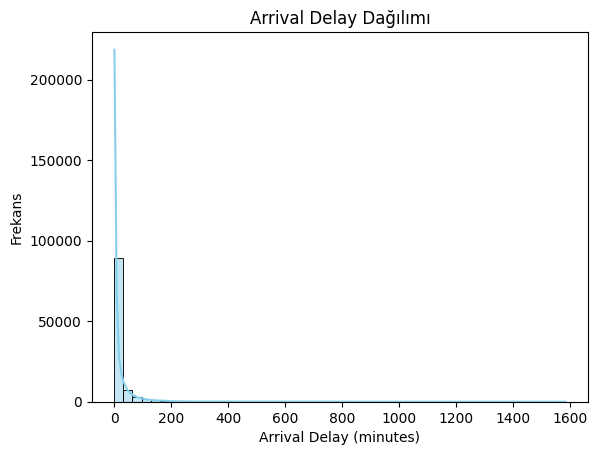

In [8]:
sns.histplot(df['Arrival Delay in Minutes'], bins=50, kde=True, color='skyblue')
plt.title('Arrival Delay Dağılımı')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frekans')
plt.show()

In [9]:
#istatistik verileri görmemizi sağlayan fonksiyon
def desc(df,column):
  mean_delay = df[column].mean()
  median_delay = df[column].median()
  skewness = df[column].skew()

  print(f"Ortalama: {mean_delay:.2f} dakika")
  print(f"Medyan: {median_delay:.2f} dakika")
  print(f"Çarpıklık (skew): {skewness:.2f}")

desc(df,'Arrival Delay in Minutes')
#eksik veriler doldurulmadan önce 'Arrival Delay in Minutes' değerleri

Ortalama: 15.18 dakika
Medyan: 0.00 dakika
Çarpıklık (skew): 6.60


Arrival Delay sütununda skewness = 6 çıktı.Bu çok güçlü bir sağa çarpıklık olduğunu gösterir. Muhtemelen az sayıda ama çok yüksek gecikmeli uçuş, dağılımı bozuyor. Bu nedenle:
İlk olarak aykırı değerleri temizleyip, ardından eksik değerleri doldurmak daha güvenilir ve dengeli bir analiz sağlar. Aykırı değerlerle uğraştıktan sonra kayıp veriler doldurulacaktır.

#2.Aykırı Değer İle Uğraşma

In [12]:
service_cols = df.loc[:, "Inflight wifi service":"Cleanliness"]
service_cols[service_cols > 5].count() #servis hizmetleri kategorisi 0-5 aralığında değer alır

,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0
Food and drink,0
Online boarding,0
Seat comfort,0
Inflight entertainment,0
On-board service,0
Leg room service,0


Hizmet memnuniyet değerlendirme kolonunda herhangi bir aykırı ya da yanlış girilmiş değer yok

<Axes: xlabel='Flight Distance'>

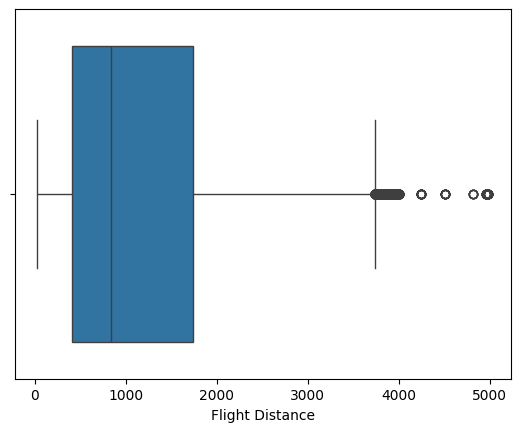

In [ ]:
sns.boxplot(x=df["Flight Distance"]) #boxplot ile aykırı değer tespiti

In [13]:
df[df["Flight Distance"]>3900].shape[0] #boxplottan elde edilen görsele göre yaklaşık kaç adet aykırı değer olduğunu bulma

878

In [ ]:
oulier_ratio=df[df["Flight Distance"]>3900].shape[0]/df.shape[0]
oulier_ratio=round(oulier_ratio,3)
oulier_ratio

0.008

%1 bile olmadığı için bu verileri dataframe i güncelleyerek sileceğim

In [14]:
df = df[df["Flight Distance"] <= 3900]

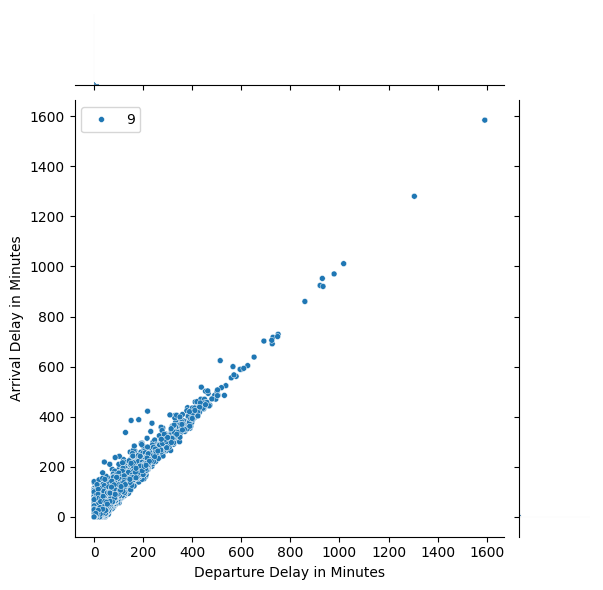

In [15]:
sns.jointplot(x="Departure Delay in Minutes", y="Arrival Delay in Minutes", data=df, size=9)

Scatter plot grafiği, kalkış ve varış gecikmeleri arasında pozitif yönlü bir ilişki olduğunu göstermektedir. Gecikmeli kalkış yapan uçuşların çoğunlukla varışta da geciktiği gözlemlenmiştir. Ancak bazı uçuşların kalkışta gecikmiş olmasına rağmen zamanında varabildiği örnekler de mevcuttur. Bu durum, uçuş esnasında hızlandırılmış operasyonların uygulanabileceğini düşündürmektedir.

Aynı anda filtreleme yöntemiyle, hem Departure Delay in Minutes hem de Arrival Delay in Minutes değişkenlerinde eşzamanlı olarak aykırı değerleri kaldıracağız. Bu sayede gereksiz veri kaybını minimuma indireceğiz ve analizimiz daha sağlıklı olacak.

In [17]:
#IQR sınırlarını hesaplayan fonksiyon
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [18]:
# Departure Delay sınırlarını al
low_dep, up_dep = iqr_bounds(df["Departure Delay in Minutes"])

# Arrival Delay sınırlarını al
low_arr, up_arr = iqr_bounds(df["Arrival Delay in Minutes"])

# Aynı anda filtreleme
filtered_df = df[
    (df["Departure Delay in Minutes"] >= low_dep) & (df["Departure Delay in Minutes"] <= up_dep) &
    (df["Arrival Delay in Minutes"] >= low_arr) & (df["Arrival Delay in Minutes"] <= up_arr)
]

print(f"Aykırılar temizlendikten sonra kalan veri sayısı: {filtered_df.shape[0]}")

Aykırılar temizlendikten sonra kalan veri sayısı: 86331


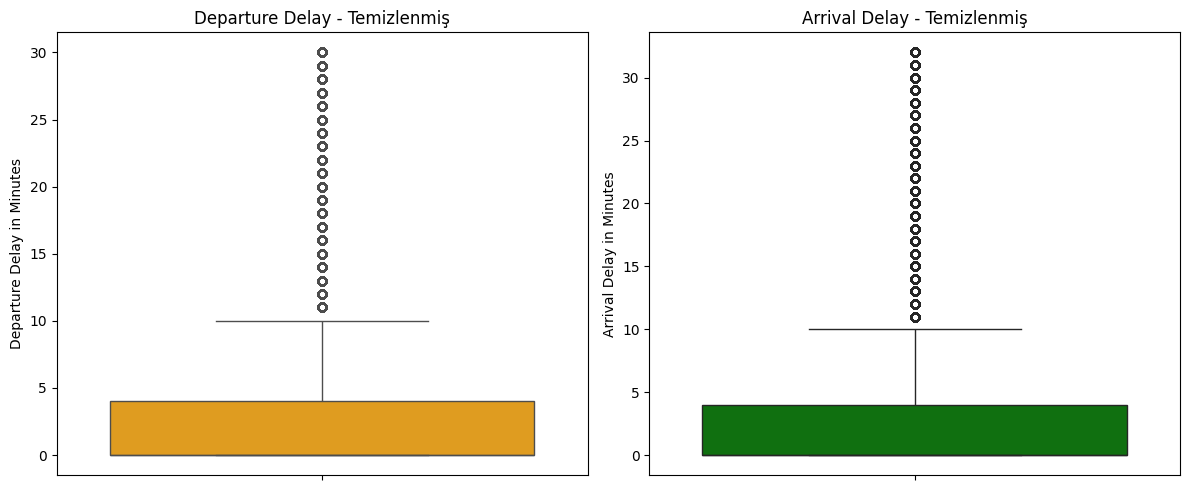

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=filtered_df["Departure Delay in Minutes"], color="orange")
plt.title("Departure Delay - Temizlenmiş")

plt.subplot(1, 2, 2)
sns.boxplot(y=filtered_df["Arrival Delay in Minutes"], color="green")
plt.title("Arrival Delay - Temizlenmiş")

plt.tight_layout()
plt.show()

“Departure ve Arrival Delay değişkenlerinde eşzamanlı olarak aykırı değer analizi yapılmıştır. IQR yöntemine göre her iki değişkenin alt ve üst sınırları belirlenmiş ve yalnızca bu sınırlar içinde kalan gözlemler analizde tutulmuştur. Bu yöntem sayesinde veri kaybı minimize edilirken analiz kalitesi korunmuştur.”

# Eksik Veriyi Doldurma

In [22]:
desc(filtered_df,'Arrival Delay in Minutes')  #aykırı değerler çıkartıldıktan sonra 'Arrival Delay in Minutes' değerleri

Ortalama: 3.54 dakika
Medyan: 0.00 dakika
Çarpıklık (skew): 2.12


Eksik değerleri medyan ile doldurmak en doğru seçenek çünkü:

*   Çoğu uçuş zaten zamanında gelmiş (medyan 0)
*   Ortalama gecikmeler birkaç uç değerin etkisinde(ortalama yanıltıcı)
*   Skewness hala yüksek










 Gözlemlerin büyük kısmı zamanında varırken, az sayıda uçuş çok uzun gecikmeler yaşamış. Bu nedenle eksik değerleri ortalama ile doldurmak, gecikmesiz uçuşların sayısını istatistiksel olarak gereksiz şekilde yükseltir. Bu nedenle medyan (0 dakika) ile doldurmak daha adildir ve dağılımın doğal yapısını bozmadan tamamlar.

In [ ]:
# Medyan ile doldurma
median_val = filtered_df['Arrival Delay in Minutes'].median()
filtered_df['Arrival Delay in Minutes'] = filtered_df['Arrival Delay in Minutes'].fillna(median_val)

# Data Wrangling(Veri Hazırlama)

**1.Sayısal değişkenlerin temel istatistikleri**

Hazırlamış olduğumuz veriye ne gibi işlemler uygulayabiliriz? Şimdi ona bakalım

In [23]:
numeric_cols = filtered_df.select_dtypes(include=["int64", "float64"]).columns
filtered_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,86331.0,65309.551911,37298.068925,1.0,33121.5,65442.0,97005.0,129880.0
Age,86331.0,39.392431,15.134170,7.0,27.0,40.0,51.0,85.0
Flight Distance,86331.0,1166.972084,968.650343,31.0,408.0,834.0,1723.0,3900.0
Inflight wifi service,86331.0,2.741564,1.337521,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,86331.0,3.061021,1.530214,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,86331.0,2.759403,1.402657,0.0,2.0,3.0,4.0,5.0
Gate location,86331.0,2.974355,1.278208,0.0,2.0,3.0,4.0,5.0
Food and drink,86331.0,3.217767,1.327554,0.0,2.0,3.0,4.0,5.0
Online boarding,86331.0,3.261609,1.351553,0.0,2.0,4.0,4.0,5.0
Seat comfort,86331.0,3.453174,1.316969,1.0,2.0,4.0,5.0,5.0


**2.Aynı uçakta olduğu varsayılan (Flight Distance aynı olan) yolcuların memnuniyeti nasıldı?**

In [69]:
# Satisfaction oranlarını yüzdesel olarak belirleme
grouped = (
    filtered_df
    .groupby('Flight Distance')['satisfaction']
    .value_counts(normalize=True)
    .rename('percentage')
    .reset_index()
)
grouped

,Flight Distance,satisfaction,percentage
0,31,neutral or dissatisfied,0.625000
1,31,satisfied,0.375000
2,56,satisfied,0.571429
3,56,neutral or dissatisfied,0.428571
4,67,neutral or dissatisfied,0.631068
...,...,...,...
6618,3898,satisfied,0.875000
6619,3898,neutral or dissatisfied,0.125000
6620,3899,satisfied,1.000000
6621,3900,neutral or dissatisfied,0.500000


In [96]:
# Her mesafe için toplam yolcu sayısı
counts = (
    filtered_df
    .groupby('Flight Distance')['satisfaction']
    .count()
    .reset_index(name='passenger_count')
)

# En az 20 kişinin aynı uçakta olduğu uçuşlar
valid_distances = counts[counts['passenger_count'] >= 20]['Flight Distance']

# Sadece bu uçuşları al
grouped_filtered = grouped[grouped['Flight Distance'].isin(valid_distances)]
grouped_filtered #n az 20 kişinin aynı uçakta olduğu(aynı mesafede uçtuğu) satisfaction yüzdesine göre gruplanmış dataframe

,Flight Distance,satisfaction,percentage
4,67,neutral or dissatisfied,0.631068
5,67,satisfied,0.368932
6,73,neutral or dissatisfied,0.707317
7,73,satisfied,0.292683
8,74,neutral or dissatisfied,0.666667
...,...,...,...
4795,2860,neutral or dissatisfied,0.380952
4892,2917,satisfied,0.575758
4893,2917,neutral or dissatisfied,0.424242
6417,3784,neutral or dissatisfied,0.586207


In [78]:
pivot_df = (
    grouped_filtered
    .pivot(index='Flight Distance', columns='satisfaction', values='percentage')
    .fillna(0)
)

pivot_df = pivot_df.sort_values(by='Flight Distance',ascending=False).head(20)

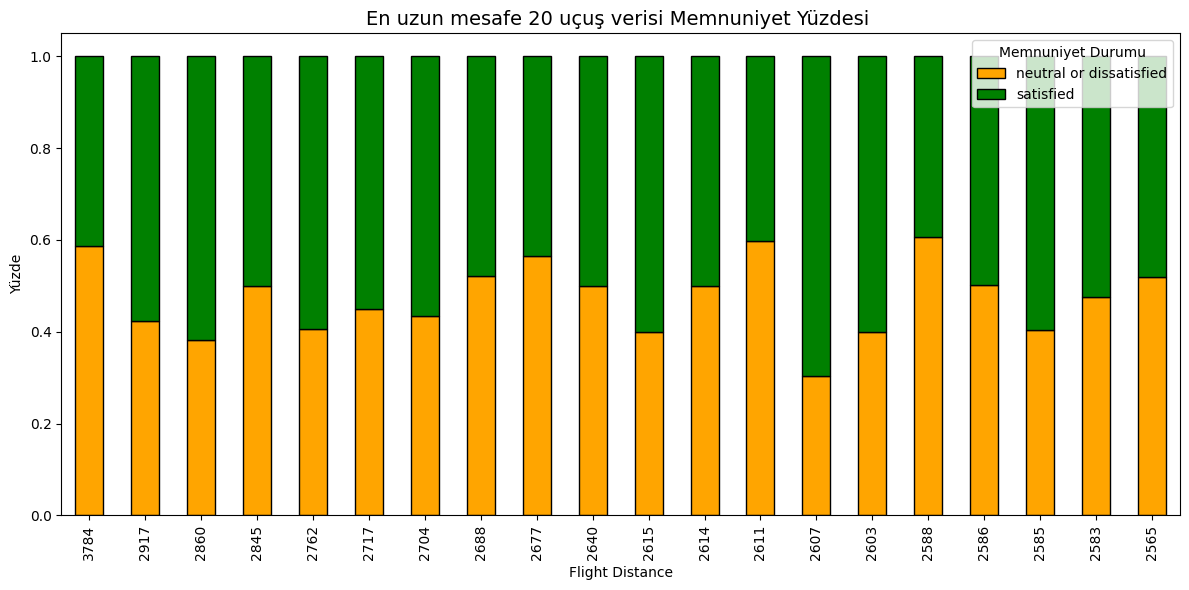

In [79]:
colors = ['orange', 'green']  # Dissatisfied - Satisfied

pivot_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 6),
    edgecolor='black'
)

plt.title('En uzun mesafe 20 uçuş verisi Memnuniyet Yüzdesi ', fontsize=14)
plt.ylabel('Yüzde')
plt.xlabel('Flight Distance')
plt.xticks(rotation=90)
plt.legend(title='Memnuniyet Durumu')
plt.tight_layout()
plt.show()

In [80]:
# İlk 20 mesafeyi seç
pivot_df = (
    grouped_filtered
    .pivot(index='Flight Distance', columns='satisfaction', values='percentage')
    .fillna(0)
)

pivot_df = pivot_df.sort_index().head(20)

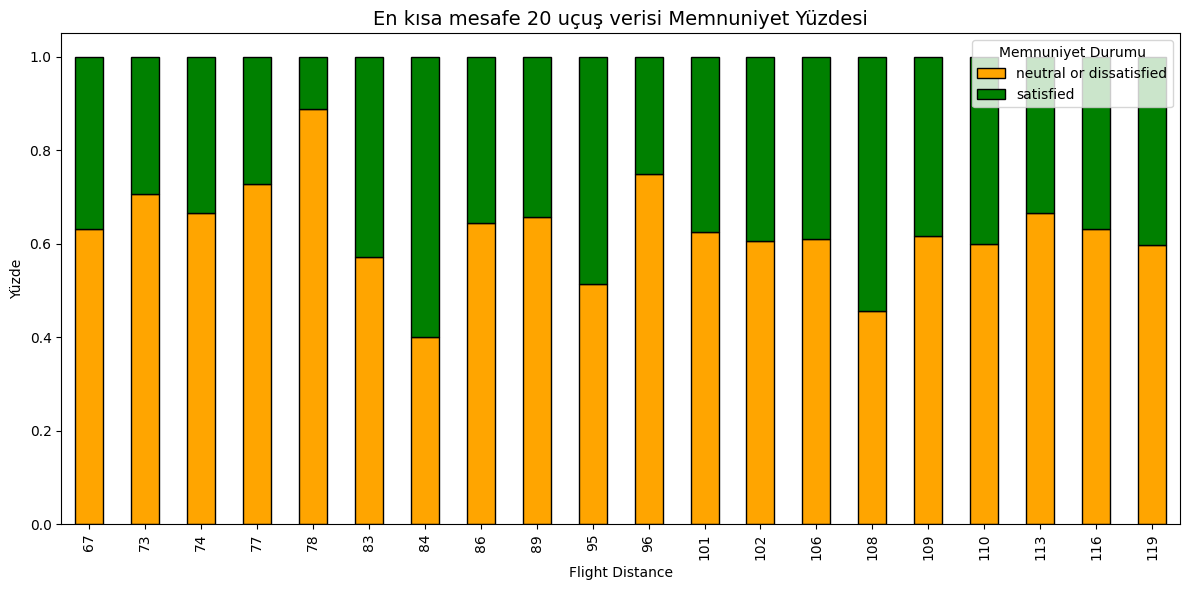

In [81]:
colors = ['orange', 'green']  # Dissatisfied - Satisfied

pivot_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 6),
    edgecolor='black'
)

plt.title('En kısa mesafe 20 uçuş verisi Memnuniyet Yüzdesi', fontsize=14)
plt.ylabel('Yüzde')
plt.xlabel('Flight Distance')
plt.xticks(rotation=90)
plt.legend(title='Memnuniyet Durumu')
plt.tight_layout()
plt.show()

Aynı uçakta olduğu varsayılan yolcular (aynı Flight Distance'a sahip olanlar) arasında memnuniyet oranı mesafeye göre farklılık göstermektedir. Kısa uçuşlarda memnuniyet oranı genellikle daha düşükken, orta ve uzun mesafelerde memnuniyet yüzdesi artış göstermektedir. Bu durum, uzun uçuşlarda verilen hizmetlerin memnuniyet üzerindeki etkisini düşündürebilir.

In [97]:
grouped_filtered=grouped_filtered.merge(counts, on='Flight Distance', how='left') #uçaktaki kişi sayısını da görebilmek için tabloları birleştirdim

filtered_rows = grouped_filtered[
    (grouped_filtered['satisfaction'] == 'neutral or dissatisfied') &
    (grouped_filtered['percentage'] > 0.80)
]


In [98]:
filtered_rows

,Flight Distance,satisfaction,percentage,passenger_count
8,78,neutral or dissatisfied,0.888889,27
56,137,neutral or dissatisfied,0.857143,21
86,159,neutral or dissatisfied,0.840000,25
338,343,neutral or dissatisfied,0.857143,21
538,482,neutral or dissatisfied,0.846154,26
584,524,neutral or dissatisfied,0.850000,20
724,624,neutral or dissatisfied,0.807692,52
852,726,neutral or dissatisfied,0.807692,26
944,809,neutral or dissatisfied,0.814815,27
1016,869,neutral or dissatisfied,0.833333,24


Analiz sonucunda, yolcularının %85’inden fazlasının memnun olmadığı 14 farklı uçuş tespit edilmiştir.

Uçuşlarda görevli pilotlar ve kabin ekipleri kimdi?

Aynı ekip başka uçuşlarda da düşük memnuniyet aldı mı?

Gecikme süreleri, uçak tipi, uçuş saati, hizmet kalitesi skorları, bu uçuşlarda farklı mıydı?

**3.** **Memnuniyet Durumuna Göre Grup Bazlı Ortalama**

 Grup bazlı ortalama karşılaştırmaları, memnuniyetin hangi hizmet kalemlerinden daha çok etkilendiğini anlamak için oldukça güçlü bir yöntemdir.

In [99]:
# Memnuniyet durumuna göre ortalama değerler
group_means=filtered_df.groupby("satisfaction")[numeric_cols].mean().T.sort_values(by="satisfied", ascending=False)

# Ortalamalar arasındaki fark
group_means["Fark (Satisfied - Dissatisfied)"] = group_means["satisfied"] - group_means["neutral or dissatisfied"]

# Farklara göre büyükten küçüğe sıralama
group_means_sorted = group_means.sort_values(by="Fark (Satisfied - Dissatisfied)", ascending=False)

# Sonuçları göster
group_means_sorted.round(2)

satisfaction,neutral or dissatisfied,satisfied,Fark (Satisfied - Dissatisfied)
id,64945.36,65763.88,818.52
Flight Distance,913.46,1483.22,569.76
Age,37.56,41.67,4.11
Online boarding,2.65,4.02,1.37
Inflight entertainment,2.90,3.96,1.06
Seat comfort,3.05,3.96,0.91
On-board service,3.03,3.86,0.83
Leg room service,2.98,3.81,0.83
Cleanliness,2.95,3.73,0.79
Inflight wifi service,2.40,3.17,0.76


Yapılan grup bazlı ortalama karşılaştırmalarına göre, Online boarding, Inflight entertainment, Seat comfort ve On-board service, memnun yolcular ile memnun olmayanlar arasında en büyük farkı yaratan hizmet kalemleridir. Bu hizmetlerdeki memnuniyet artışı, yolcunun genel tatmin düzeyini doğrudan etkilemektedir.

Buna karşın Gate location, Ease of Online booking ve Food and drink gibi hizmetler, memnuniyet üzerinde daha düşük fark yaratmakta; bu da yolcuların bu hizmetleri daha "nötr" değerlendirdiğini göstermektedir.

Özellikle “Online boarding” sisteminin kullanıcı dostu hale getirilmesi, doğrudan memnuniyet oranlarını artırabilir.

Bu içgörüler pazarlama ve operasyon ekipleriyle paylaşılmalı ve kullanıcı dostu arayüz desteği sağlanmalıdır.

 Ortalamalar arasında fark gözle görülür ama bu farklar istatistiksel olarak anlamlı mı bunu test etmek gerekir. Bu tür durumlar için bağımsız örneklem t-testi (independent samples t-test) kullanılır.

H0 (sıfır hipotezi): Grup ortalamaları arasında anlamlı fark yoktur.

p-değeri < 0.05 ise: fark anlamlıdır, H0 reddedilir. Yani anlamlı farklılık vardır.

In [ ]:
from scipy.stats import ttest_ind

satisfied_group = filtered_df[filtered_df["satisfaction"] == "satisfied"]
dissatisfied_group = filtered_df[filtered_df["satisfaction"] == "neutral or dissatisfied"]

results = []

for feature in numeric_cols:
    stat, p = ttest_ind(
        satisfied_group[feature].dropna(),
        dissatisfied_group[feature].dropna(),
        equal_var=False  # varyanslar eşit olmayabilir, daha güvenli
    )
    results.append({
        "Değişken": feature,
        "p-değeri": round(p, 4),
        "Anlamlı mı (p<0.05)": "Evet" if p < 0.05 else "Hayır"
    })

# Sonuçları tablo olarak göster
import pandas as pd
pd.DataFrame(results).sort_values("p-değeri")

,Değişken,p-değeri,Anlamlı mı (p<0.05)
1,Age,0.0000,Evet
2,Flight Distance,0.0000,Evet
3,Inflight wifi service,0.0000,Evet
4,Departure/Arrival time convenient,0.0000,Evet
7,Food and drink,0.0000,Evet
5,Ease of Online booking,0.0000,Evet
9,Seat comfort,0.0000,Evet
8,Online boarding,0.0000,Evet
12,Leg room service,0.0000,Evet
13,Baggage handling,0.0000,Evet


Yapılan bağımsız örneklem t-testleri sonucunda, yolcuların memnuniyet durumu ile birçok hizmet kalemi arasında istatistiksel olarak anlamlı farklar bulundu.

**4. Yeni sütun ekleme**

In [156]:
filtered_df["had_delay"] = (filtered_df["Departure Delay in Minutes"] > 10) | (filtered_df["Arrival Delay in Minutes"] > 10)
# kalkış veya varışta 10 dakika gecikme yaşayan kişilere true döndüren boolean sütun

/tmp/ipython-input-156-3287839672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["had_delay"] = (filtered_df["Departure Delay in Minutes"] > 10) | (filtered_df["Arrival Delay in Minutes"] > 10)


 **5. Müşteri Tipine Göre Hizmet Algısı (Apply ile)**

In [102]:
# Hizmet puanları kolonları

service_cols = filtered_df.loc[:, "Inflight wifi service":"Cleanliness"]  # hizmetle ilgili 1-5 arası skala içeren sütunlar
service_cols.head(5)

,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
0,3,4,3,1,5,3,5,5,4,3,4,4,5,5
1,3,2,3,3,1,3,1,1,1,5,3,1,4,1
2,2,2,2,2,5,5,5,5,4,3,4,4,4,5
3,2,5,5,5,2,2,2,2,2,5,3,1,4,2
4,3,3,3,3,4,5,5,3,3,4,4,3,3,3


In [107]:
# Kişi bazlı ortalama memnuniyet skoru
filtered_df.loc[:,["avg_service_score"]] = service_cols.mean(axis=1).round(2)
filtered_df["avg_service_score"].head()

,avg_service_score
0,3.86
1,2.29
2,3.71
3,3.00
4,3.50


In [111]:
# Apply ile müşteri bazlı etiketleme

def classify_customer(row):
    if row["avg_service_score"] > 4 and row["Customer Type"] == "Loyal Customer":
        return "Sadık & Memnun"

    elif row["avg_service_score"] < 2.5 and row["Customer Type"] == "Loyal Customer":
        return "Memnuniyetsiz & Sadık"

    elif row["avg_service_score"] < 2.5 and row["Customer Type"] == "disloyal Customer":
        return "Memnuniyetsiz & Sadık Olmayan"

    elif row["avg_service_score"] > 4 and row["Customer Type"] == "disloyal Customer":
      return "Memnun & Sadık Olmayan"

    else:
      return " Orta seviye"

filtered_df.loc[:,["Customer_Profile"]]=filtered_df.apply(classify_customer, axis=1)


filtered_df["Customer_Profile"].value_counts()

,count
Customer_Profile,
Orta seviye,64368
Sadık & Memnun,9973
Memnuniyetsiz & Sadık,8385
Memnuniyetsiz & Sadık Olmayan,2734
Memnun & Sadık Olmayan,871


Veri setinde "Sadık ve Memnun" müşteriler önemli bir segmenti oluşturuyor. Ancak "Memnuniyetsiz ve Sadık Olmayan" sınıfı da kaybedilmeye açık bir grubu temsil ediyor. Ayrıca "Memnuniyetsiz & Sadık" müşerilerimizi kaybetmemek adına onlara özel aksşyon alabiliriz.

Peki servis skoru yüksek ama memnun kalmayan müşterilerimiz ne için memnun kalmamış olabilir?



In [157]:
mask = (
    (filtered_df["avg_service_score"] > 3.5) &
    (filtered_df["satisfaction"] == "neutral or dissatisfied")
)

filtered_subset = filtered_df[mask]
print(filtered_subset.shape[0])  # kaç kişi bu durumda

7873


Bu müşteriler uçak içi hizmetleri (koltuk, ikram, eğlence vb.) yüksek puanlamış ama yine de genel memnuniyetsizlik belirtmiş. Sebepleri neler olabilir?

1.   Gecikmeler
2.   Müşteri Tipi Etkisi(çoğu disloyal müşteri olabilir,önceki kötü deneyimler)
3.   İş seyahati yapanlar hassas olabilir(toplantıya geç kalma)
4.   Sınıf etkisi( Business class yolcuları beklenti olarak daha yüksektir)

Bu da gösteriyor ki, uçak içi hizmet kalitesi iyi olsa bile operasyonel faktörler (özellikle zamanında kalkış/varış) ve kişisel bağlam (seyahat amacı, sadakat durumu) memnuniyet üzerinde etkiye sahiptir.

**6. Servis skoru yüksek ama memnuniyetsiz olma sebepleri**

In [158]:
#Servis skoru yüksek olanlar neden memnun olmamış olabilir?Gecikmeler

delay_counts = filtered_subset['had_delay'].value_counts(normalize=True)

print(delay_counts)

had_delay
False    0.780389
True     0.219611
Name: proportion, dtype: float64


Hizmet puanı yüksek olmasına rağmen %21’i gecikmeli uçmuş. Yani memnuniyetsizlik başka değişkenelerden daha çok etkilenmiş olabilir. Ayrıca satisfied sütununun satisfied ve neutral or dissatisfied olarak etiketlenmesi bize yanıltıcı sonuçlar veriyor. Bu nedenle memnuniyet butonu 3 kısma ayrılabilir.

1.Satisfied

2.Neutral

3.Dissatisfied

/tmp/ipython-input-159-2662533190.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


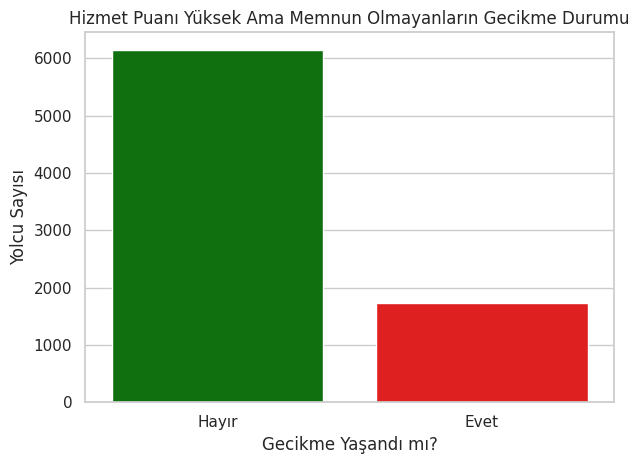

In [159]:
sns.countplot(
    data=filtered_subset,
    x='had_delay',
    palette=['green', 'red']
)

plt.title('Hizmet Puanı Yüksek Ama Memnun Olmayanların Gecikme Durumu')
plt.xlabel('Gecikme Yaşandı mı?')
plt.ylabel('Yolcu Sayısı')
plt.xticks([0, 1], ['Hayır', 'Evet'])
plt.tight_layout()
plt.show()

#Sayısal Analiz ve Görselleştirme


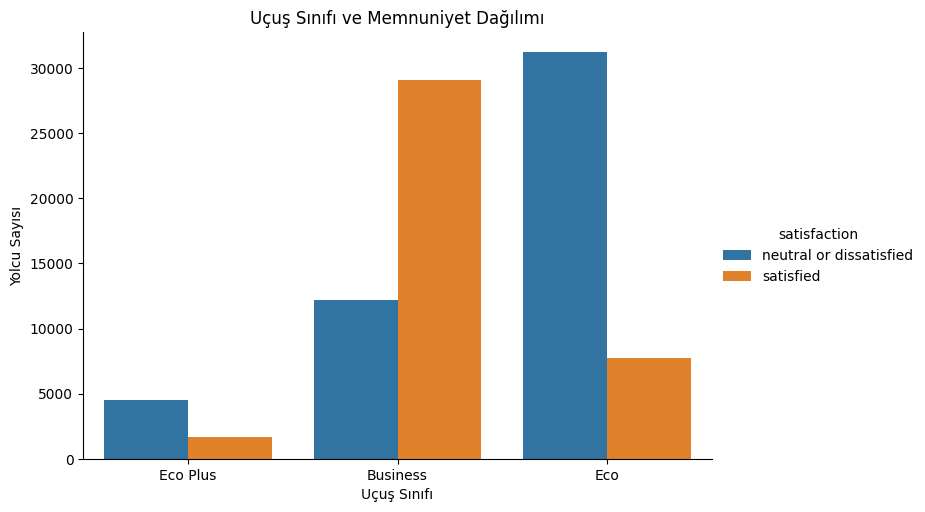

In [112]:
#uçuş sınıfına göre memnuniyet dağılımı
sns.catplot(data=filtered_df, x="Class", hue="satisfaction", kind="count", height=5, aspect=1.5)
plt.title("Uçuş Sınıfı ve Memnuniyet Dağılımı")
plt.xlabel("Uçuş Sınıfı")
plt.ylabel("Yolcu Sayısı")
plt.show()

Business Class yolcularının diğer sınıflara kıyasla çok daha yüksek memnuniyet oranına sahip olduğu görülüyor.

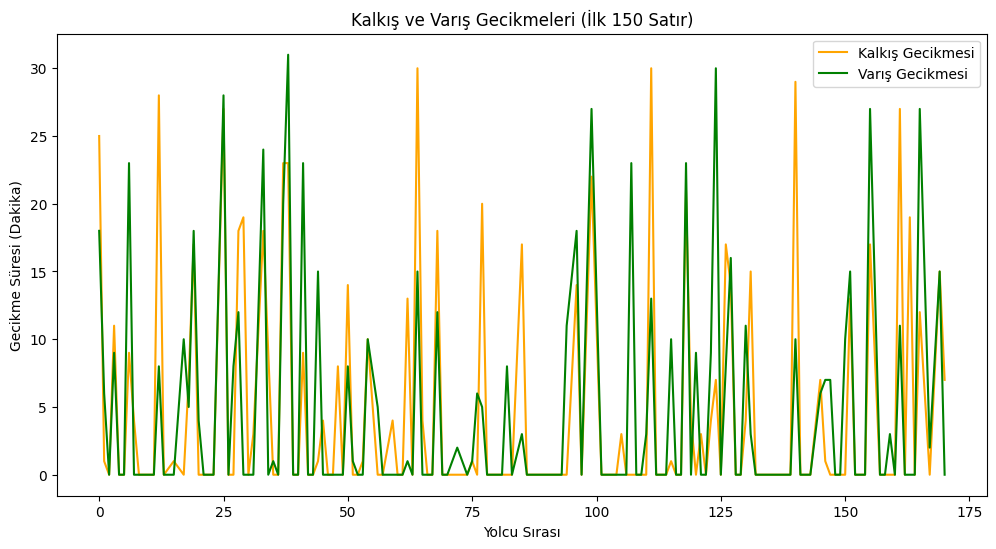

In [113]:
# İlk 150 satırı al
df_sample = filtered_df[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].head(150)

plt.figure(figsize=(12,6))
plt.plot(df_sample["Departure Delay in Minutes"], label="Kalkış Gecikmesi", color="orange")
plt.plot(df_sample["Arrival Delay in Minutes"], label="Varış Gecikmesi", color="green")
plt.title("Kalkış ve Varış Gecikmeleri (İlk 150 Satır)")
plt.xlabel("Yolcu Sırası")
plt.ylabel("Gecikme Süresi (Dakika)")
plt.legend()


Varış gecikmelerinin kalkış gecikmelerine kıyasla daha az olduğu, yolculuk sırasında pilotun gecikmeyi tolere edebileceği görülmektedir.

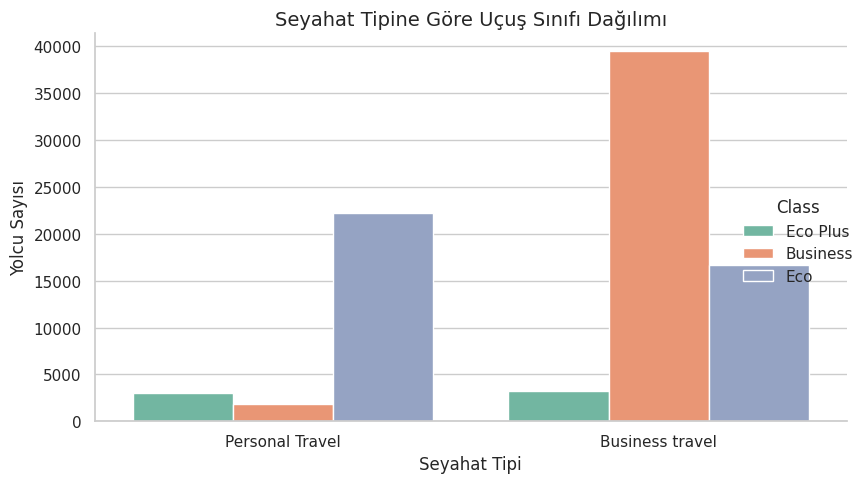

In [129]:
sns.set(style="whitegrid")

sns.catplot(
    data=filtered_df,
    x="Type of Travel",
    hue="Class",
    kind="count",
    height=5,
    aspect=1.5,
    palette="Set2"
)

plt.title("Seyahat Tipine Göre Uçuş Sınıfı Dağılımı", fontsize=14)
plt.ylabel("Yolcu Sayısı")
plt.xlabel("Seyahat Tipi")
plt.tight_layout()
plt.show()

In [133]:
# Her seyahat tipi ve class için satisfaction yüzdesi
grouped_pct = (
    filtered_df
    .groupby(['Type of Travel', 'Class'])['satisfaction']
    .value_counts(normalize=True)
    .rename('percentage')
    .reset_index()
)

# Sadece 'satisfied' olanlar
satisfied_pct = grouped_pct[grouped_pct['satisfaction'] == 'satisfied']

grouped_pct

,Type of Travel,Class,satisfaction,percentage
0,Business travel,Business,satisfied,0.730874
1,Business travel,Business,neutral or dissatisfied,0.269126
2,Business travel,Eco,neutral or dissatisfied,0.688126
3,Business travel,Eco,satisfied,0.311874
4,Business travel,Eco Plus,neutral or dissatisfied,0.579195
5,Business travel,Eco Plus,satisfied,0.420805
6,Personal Travel,Business,neutral or dissatisfied,0.865697
7,Personal Travel,Business,satisfied,0.134303
8,Personal Travel,Eco,neutral or dissatisfied,0.887590
9,Personal Travel,Eco,satisfied,0.112410


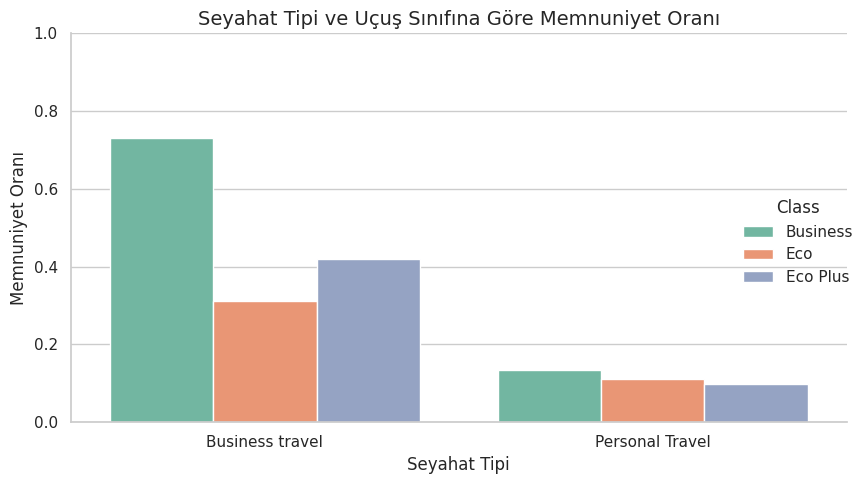

In [132]:
sns.catplot(
    data=satisfied_pct,
    x='Type of Travel',
    y='percentage',
    hue='Class',
    kind='bar',
    height=5,
    aspect=1.5,
    palette='Set2'
)

plt.title("Seyahat Tipi ve Uçuş Sınıfına Göre Memnuniyet Oranı", fontsize=14)
plt.ylabel("Memnuniyet Oranı")
plt.xlabel("Seyahat Tipi")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Bu grafik, her seyahat tipi içinde farklı sınıflarda yolcuların memnuniyet oranlarını karşılaştırmaktadır.
İş seyahatlerinde business class yolcularının memnuniyet oranı oldukça yüksekken, economy class'ta bu oran düşüktür.